# 文件: chart_12_1.py

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_61312\2257106501.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="categoria", y="porcentaje", data=datos_genero, palette=["#ff6b6b", "#48dbfb"], ax=ax1)


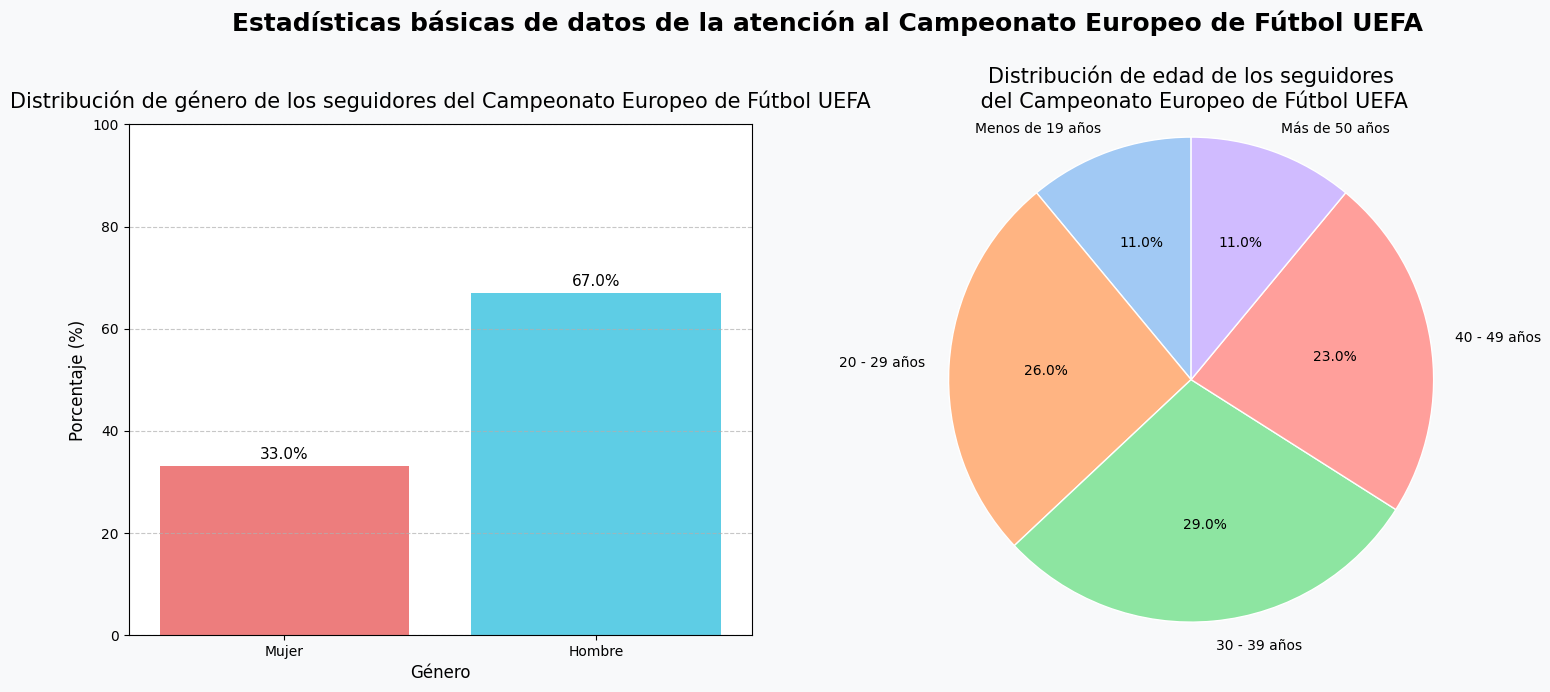

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Construir datos
datos = {
    "categoria": ["Mujer", "Hombre", "Menos de 19 años", "20 - 29 años", "30 - 39 años", "40 - 49 años", "Más de 50 años"],
    "porcentaje": [33, 67, 11, 26, 29, 23, 11]
}
df = pd.DataFrame(datos)

# Clasificar datos en grupos de género y edad
datos_genero = df.iloc[:2]
datos_edad = df.iloc[2:]

# Crear un lienzo con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')  # Establecer el color de fondo del lienzo

# Embelezar el gráfico de barras - Distribución de género
sns.barplot(x="categoria", y="porcentaje", data=datos_genero, palette=["#ff6b6b", "#48dbfb"], ax=ax1)
ax1.set_title("Distribución de género de los seguidores del Campeonato Europeo de Fútbol UEFA", fontsize=15, pad=12)
ax1.set_xlabel("Género", fontsize=12)
ax1.set_ylabel("Porcentaje (%)", fontsize=12)
ax1.set_ylim(0, 100)  # Establecer el rango del eje y
ax1.grid(axis='y', linestyle='--', alpha=0.7)  # Optimizar las líneas de la cuadrícula

# Añadir etiquetas numéricas para la distribución de género
for p in ax1.patches:
    altura = p.get_height()
    ax1.text(p.get_x() + p.get_width() / 2., altura + 1.5,
             f'{altura:.1f}%', ha="center", fontsize=11)

# Embelezar el gráfico circular - Distribución de edad
wedges, texts, autotexts = ax2.pie(
    datos_edad["porcentaje"],
    labels=datos_edad["categoria"],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': 'w', 'linewidth': 1},
    textprops={'fontsize': 10}
)
ax2.set_title("Distribución de edad de los seguidores\n del Campeonato Europeo de Fútbol UEFA", fontsize=15, pad=12)
ax2.axis('equal')  # Asegurar que el gráfico circular sea un círculo perfecto

# Ajustar el diseño
plt.tight_layout(pad=3)  # Aumentar el espacio entre los subgráficos
plt.suptitle("Estadísticas básicas de datos de la atención al Campeonato Europeo de Fútbol UEFA", fontsize=18, y=1.02, fontweight='bold')

# Mostrar el gráfico
plt.show()

# 文件: chart_12_2.py

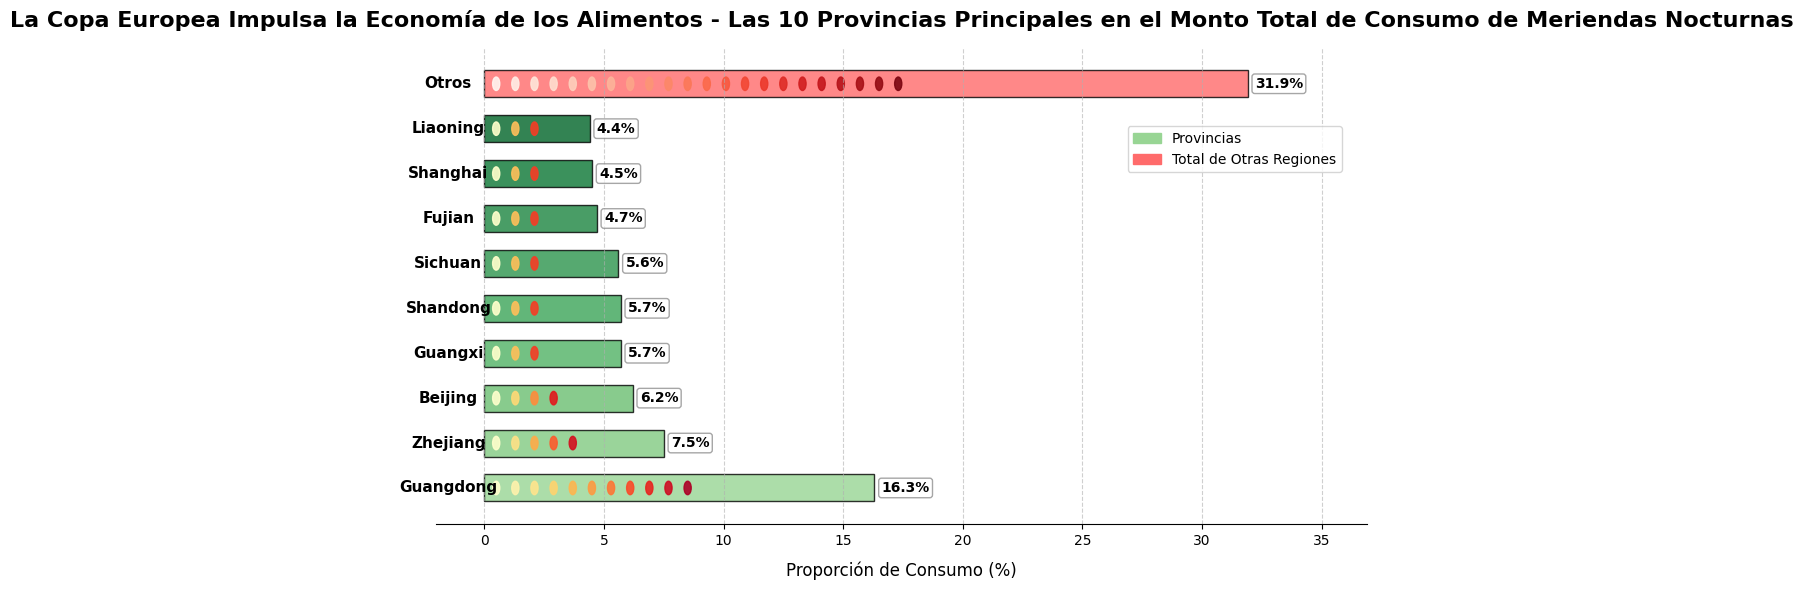

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Construir datos
provincias = ["Guangdong", "Zhejiang", "Beijing", "Guangxi", "Shandong", "Sichuan", "Fujian", "Shanghai", "Liaoning", "Otros"]
porcentajes = [16.3, 7.5, 6.2, 5.7, 5.7, 5.6, 4.7, 4.5, 4.4, 31.9]

# Crear un lienzo y ejes
fig, ax = plt.subplots(figsize=(10, 6))

# Establecer colores degradados (usar un color diferente para "Otros", y degradados para el resto de las provincias)
color_otros = '#FF6B6B'  # Rojo para "Otros"
colores_provincias = plt.cm.Greens(np.linspace(0.4, 0.9, len(provincias) - 1))
colores = list(colores_provincias) + [color_otros]  # Degradados de provincias primero, seguidos del color para "Otros"

# Dibujar un gráfico de barras horizontales
ancho_barra = 0.6
posicion_y = np.arange(len(provincias))
barras = ax.barh(posicion_y, porcentajes, height=ancho_barra, color=colores, edgecolor='black', alpha=0.8)

# Personalizar el estilo "kebab"
for i, (provincia, porcentaje) in enumerate(zip(provincias, porcentajes)):
    # Calcular el número de cuentas
    cantidad_cuentas = max(1, int(porcentaje * 0.7))  # Determinar el número de cuentas en función del porcentaje

    # Dibujar las cuentas (círculos)
    for j in range(cantidad_cuentas):
        x_cuenta = 0.5 + j * 0.8  # Posición x de la cuenta
        if x_cuenta < porcentaje - 0.5:  # Asegurarse de que las cuentas no excedan el rango de la barra
            # Usar cuentas rojas para el elemento "Otros", y degradados amarillos para el resto
            if i == len(provincias) - 1:
                color_cuenta = plt.cm.Reds(j/cantidad_cuentas)
            else:
                color_cuenta = plt.cm.YlOrRd(j/cantidad_cuentas)
            circulo = mpatches.Circle(
                (x_cuenta, posicion_y[i]),
                radius=0.15,
                color=color_cuenta,
                alpha=0.9
            )
            ax.add_patch(circulo)

    # Agregar etiquetas de provincia (a la izquierda)
    ax.text(-1.5, posicion_y[i], provincia, ha='center', va='center', fontweight='bold', fontsize=11)

# Agregar etiquetas de valores de porcentaje (con cajas de fondo)
for i, rect in enumerate(barras):
    ancho = rect.get_width()
    ax.text(
        ancho + 0.3, rect.get_y() + rect.get_height()/2,
        f'{porcentajes[i]:.1f}%',  # Mantener un decimal
        ha='left', va='center',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.2')
    )

# Establecer los ejes y el título
ax.set_xlim(-2, max(porcentajes) + 5)  # Ajustar el rango del eje x
ax.set_ylim(-0.8, len(provincias) - 0.2)  # Ajustar el rango del eje y
ax.set_title('La Copa Europea Impulsa la Economía de los Alimentos - Las 10 Provincias Principales en el Monto Total de Consumo de Meriendas Nocturnas', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Proporción de Consumo (%)', fontsize=12, labelpad=10)
ax.set_yticks([])  # Ocultar las etiquetas predeterminadas del eje y

# Agregar líneas de cuadrícula
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Agregar una leyenda y moverla hacia abajo
parche_provincia = mpatches.Patch(color=colores_provincias[0], label='Provincias')
parche_otros = mpatches.Patch(color=color_otros, label='Total de Otras Regiones')
ax.legend(handles=[parche_provincia, parche_otros],
          loc='upper right',
          bbox_to_anchor=(0.98, 0.85))  # Ajustar el parámetro bbox_to_anchor para moverla hacia abajo

# Difuminar el borde
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# 文件: chart_12_3.py

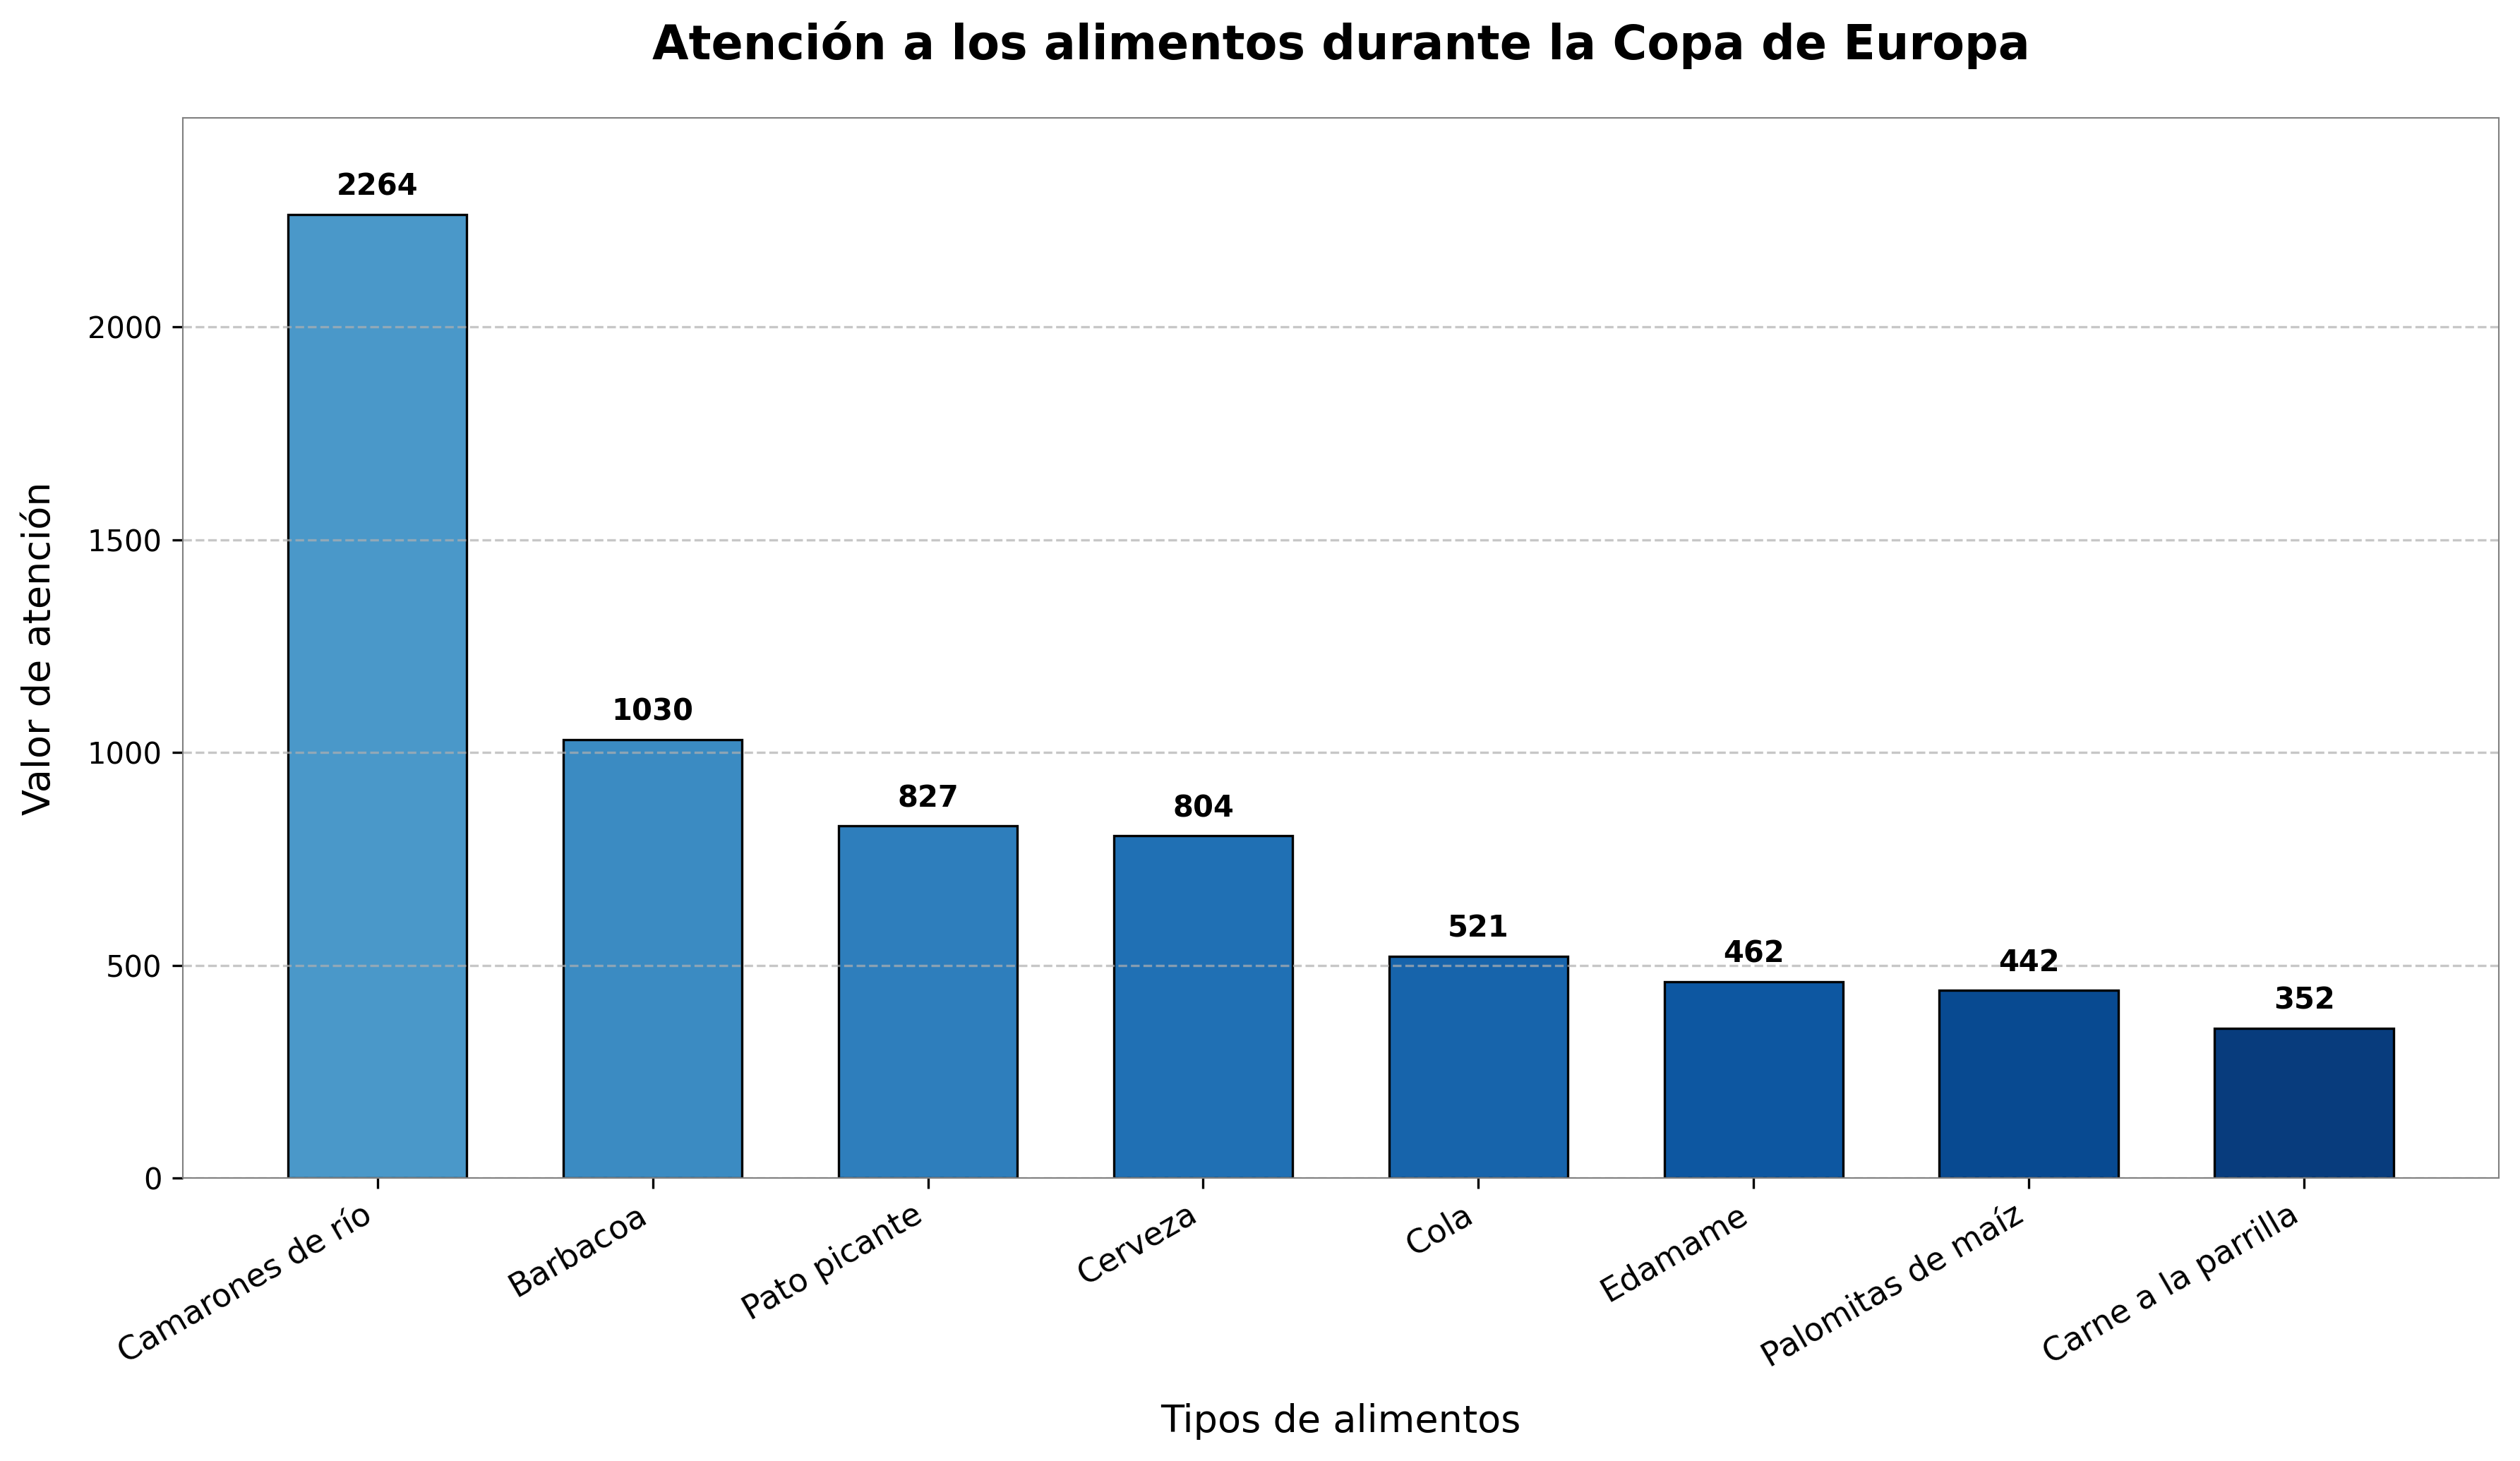

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
comidas = ["Camarones de río", "Barbacoa", "Pato picante", "Cerveza", "Cola", "Edamame", "Palomitas de maíz", "Carne a la parrilla"]
valores = [2264, 1030, 827, 804, 521, 462, 442, 352]

# Crear un lienzo y un sub - gráfico (establecer un tamaño y resolución más grandes)
fig, ax = plt.subplots(figsize=(12, 7), dpi = 300)

# Establecer colores degradados (de azul oscuro a azul claro)
colores = plt.cm.Blues(np.linspace(0.6, 0.95, len(comidas)))

# Dibujar un gráfico de barras con esquinas redondeadas (establecer el borde mediante edgecolor y linewidth)
barras = ax.bar(
    x = np.arange(len(comidas)),
    height = valores,
    width = 0.65,
    color = colores,
    edgecolor = 'black',
    linewidth = 0.8,
    capstyle = 'round'
)

# Agregar etiquetas numéricas encima del gráfico de barras
for barra, valor in zip(barras, valores):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2., 
        altura + 30,  # La posición de la etiqueta está ligeramente por encima de la parte superior de la barra
        f'{valor}',
        ha = 'center', 
        va = 'bottom',
        fontsize = 10,
        fontweight = 'bold'
    )

# Establecer las etiquetas de las marcas del eje x (girar 30 grados para mejorar la legibilidad)
ax.set_xticks(np.arange(len(comidas)))
ax.set_xticklabels(comidas, rotation = 30, ha = 'right', fontsize = 11)

# Agregar un título y etiquetas de los ejes (aumentar el tamaño de fuente y la negrita)
ax.set_title('Atención a los alimentos durante la Copa de Europa', fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Tipos de alimentos', fontsize = 13, labelpad = 10)
ax.set_ylabel('Valor de atención', fontsize = 13, labelpad = 10)

# Establecer el rango del eje y (dejar algo de espacio en la parte superior)
ax.set_ylim(0, max(valores) * 1.1)

# Agregar líneas de cuadrícula para mejorar la legibilidad
ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)

# Embellir el borde del gráfico
for spine in ax.spines.values():
    spine.set_color('gray')
    spine.set_linewidth(0.5)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# 文件: chart_12_4.py

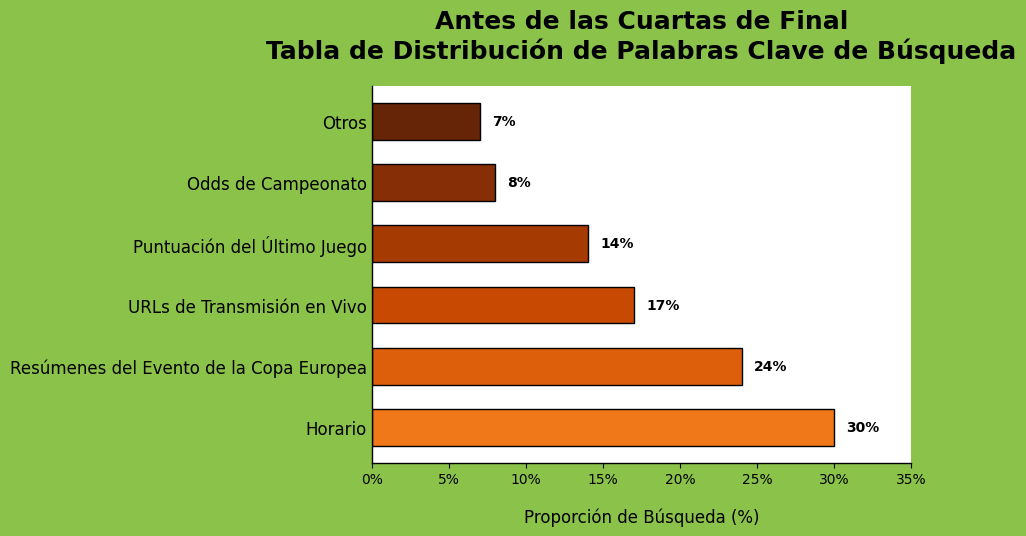

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Preparación de datos
etiquetas = ["Horario", "Resúmenes del Evento de la Copa Europea", "URLs de Transmisión en Vivo", "Puntuación del Último Juego", "Odds de Campeonato", "Otros"]
porcentajes = [30, 24, 17, 14, 8, 7]

# Crear un lienzo y un sub - gráfico
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#8BC34A')  # Fondo verde

# Dibujar un gráfico de barras horizontales (usando un gradiente amarillo)
posicion_y = np.arange(len(etiquetas))
colores = plt.cm.YlOrBr(np.linspace(0.6, 1, len(etiquetas)))  # Gradiente de amarillo a naranja
barras = ax.barh(posicion_y, porcentajes, color=colores, edgecolor='black', height=0.6)

# Añadir un título y un subtítulo
ax.set_title('Antes de las Cuartas de Final\nTabla de Distribución de Palabras Clave de Búsqueda', fontsize=18, fontweight='bold', pad=20)

# Establecer las etiquetas del eje y (palabras clave)
ax.set_yticks(posicion_y)
ax.set_yticklabels(etiquetas, fontsize=12)
ax.tick_params(axis='y', which='both', length=0)  # Ocultar las marcas de graduación del eje y

# Establecer las etiquetas del eje x (porcentajes)
ax.set_xlabel('Proporción de Búsqueda (%)', fontsize=12, labelpad=15)
ax.set_xlim(0, 35)  # Dejar espacio en el lado derecho
ax.set_xticks(np.arange(0, 36, 5))
ax.set_xticklabels([f'{x}%' for x in np.arange(0, 36, 5)], fontsize=10)

# Añadir etiquetas numéricas a cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.text(ancho + 0.8, barra.get_y() + barra.get_height()/2,
            f'{ancho}%', ha='left', va='center', fontsize=10, fontweight='bold')

# Añadir "Iconos de Persona" (usando formas nativas de matplotlib en su lugar)
for i, (etiqueta, porcentaje) in enumerate(zip(etiquetas, porcentajes)):
    # Dibujar una "persona" simplificada (una cabeza circular + un cuerpo rectangular)
    cabeza = plt.Circle((-2.5, posicion_y[i]), 0.3, color='yellow', ec='black')
    cuerpo = plt.Rectangle((-2.8, posicion_y[i]-0.3), 0.6, 0.6, color='yellow', ec='black')
    ax.add_patch(cabeza)
    ax.add_patch(cuerpo)

    # Añadir una marca de "Corazón" (usando un triángulo en su lugar)
    x_corazon = [-2.6, -2.4, -2.5]
    y_corazon = [posicion_y[i]+0.15, posicion_y[i]+0.15, posicion_y[i]+0.3]
    ax.fill(x_corazon, y_corazon, color='red')

# Añadir marcas de "Lupa" (usando formas nativas de matplotlib)
for i, p in enumerate(porcentajes):
    num_lupas = p // 5
    for j in range(num_lupas):
        # Dibujar una lupa simplificada
        x_lupa = [-5 - j*0.8, -4.5 - j*0.8, -4.7 - j*0.8, -5 - j*0.8]
        y_lupa = [posicion_y[i]+0.1, posicion_y[i]+0.1, posicion_y[i]-0.1, posicion_y[i]-0.1]
        ax.fill(x_lupa, y_lupa, color='black')
        # Mango de la lupa
        ax.plot([-4.5 - j*0.8, -4.3 - j*0.8], [posicion_y[i], posicion_y[i]-0.2], 'k-', linewidth=1.5)

# Ocultar los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# Ajustar el diseño
plt.tight_layout(pad=3)
plt.show()

# 文件: chart_12_5.py

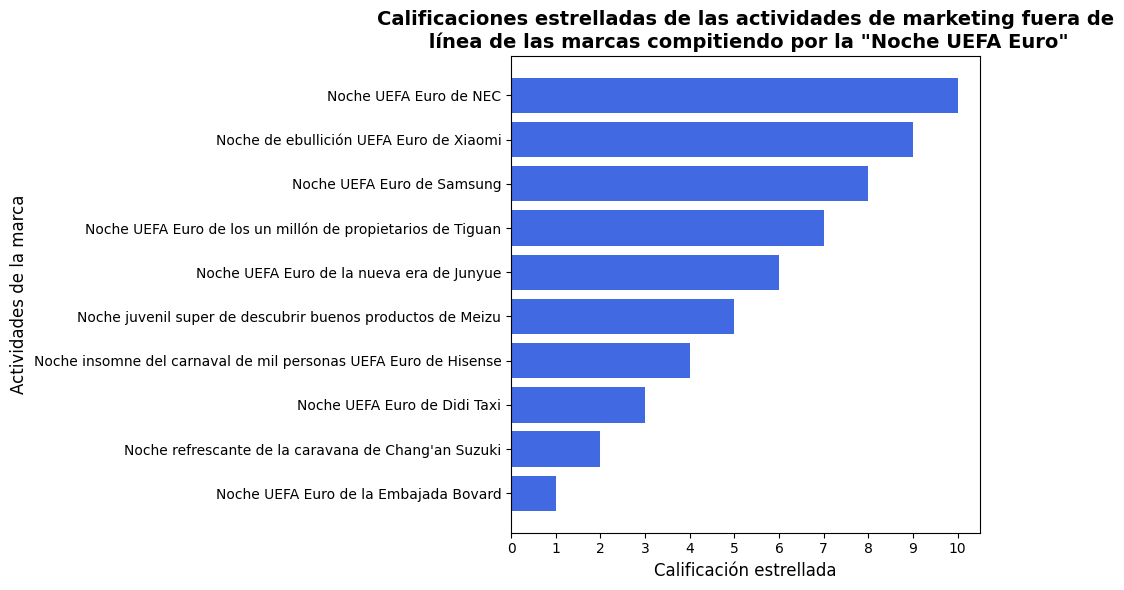

In [1]:
import matplotlib.pyplot as plt

# Datos
marcas = [
    "Noche UEFA Euro de NEC",
    "Noche de ebullición UEFA Euro de Xiaomi",
    "Noche UEFA Euro de Samsung",
    "Noche UEFA Euro de los un millón de propietarios de Tiguan",
    "Noche UEFA Euro de la nueva era de Junyue",
    "Noche juvenil super de descubrir buenos productos de Meizu",
    "Noche insomne del carnaval de mil personas UEFA Euro de Hisense",
    "Noche UEFA Euro de Didi Taxi",
    "Noche refrescante de la caravana de Chang'an Suzuki",
    "Noche UEFA Euro de la Embajada Bovard"
]
calificaciones = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

# Crear un lienzo y un sub - gráfico
fig, ax = plt.subplots(figsize=(10, 6))  # figsize puede ajustar el tamaño del gráfico

# Dibujar un gráfico de barras horizontales
ax.barh(marcas[::-1], calificaciones[::-1], color='royalblue')

# Establecer el título y las etiquetas de los ejes
ax.set_title('Calificaciones estrelladas de las actividades de marketing fuera de\n línea de las marcas compitiendo por la "Noche UEFA Euro"', fontsize=14, fontweight='bold')
ax.set_xlabel('Calificación estrellada', fontsize=12)
ax.set_ylabel('Actividades de la marca', fontsize=12)

# Establecer las marcas del eje x (de 0 a 10 según las calificaciones estrelladas)
ax.set_xticks(range(0, 11))

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el diseño para evitar la superposición de etiquetas
plt.show()